In [1]:
# Test script 3

In [5]:
# Option 3 for mortality equation (no extra population weighting) TEST FOR 2000

In [11]:
import os
import xarray as xr
import regionmask
import matplotlib.pyplot as plt
import numpy as np

In [2]:
BMR_DIR = "/glade/work/awells/air_quality/BMR/"
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"
O3_DIR = "/glade/work/awells/air_quality/O3_obs/"

In [4]:
bmr = xr.open_dataarray(f"{BMR_DIR}GBD_BMR_Country_Mask_COPD_1990-2009.nc")
pop_2000 = xr.open_dataarray(f"{POP_DIR}ssp2_total_regrid_2000.nc")
o3_2000 = xr.open_dataset(f"{O3_DIR}Delang_BME_OSDMA8_1990_2017.nc")["ozone"].sel(year=slice("1990", "2009")).mean("year")

In [5]:
pop_lat = pop_2000.lat.values
pop_lon = pop_2000.lon.values

o3_lat = o3_2000.latitude.values
o3_lon = o3_2000.longitude.values

bmr_lat = bmr.lat.values
bmr_lon = bmr.lon.values

In [6]:
o3_lat_mask = xr.ufuncs.logical_and(o3_lat <= pop_lat.max(), o3_lat >= pop_lat.min())
o3_lon_mask = xr.ufuncs.logical_and(o3_lon <= pop_lon.max(), o3_lon >= pop_lon.min())

bmr_lat_mask = xr.ufuncs.logical_and(bmr_lat <= pop_lat.max(), bmr_lat >= pop_lat.min())
bmr_lon_mask = xr.ufuncs.logical_and(bmr_lon <= pop_lon.max(), bmr_lon >= pop_lon.min())

In [7]:
new_o3 = o3_2000.sel(latitude=o3_lat_mask)
new_bmr = bmr.sel(lat=bmr_lat_mask)

In [8]:
o3_interp = new_o3.interp(latitude=pop_2000.lat, longitude=pop_2000.lon, method="linear")
bmr_interp = new_bmr.interp(lat=pop_2000.lat, lon=pop_2000.lon, method="linear")

In [155]:
RR_10ppb = 1.074
# RR = e^(beta*(x-TMREL))
beta = np.log(RR_10ppb)/10
TMREL = 32.4

In [156]:
O3_diff = o3_interp - TMREL
TMREL_O3 = xr.where(O3_diff > 0, O3_diff, 0)

In [157]:
RR = np.exp(beta * TMREL_O3)

In [158]:
AF = (RR - 1)/RR

In [139]:
# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da

In [159]:
M = AF * bmr_interp * pop_2000

In [151]:
M_no_o3 = bmr_interp * pop_2000

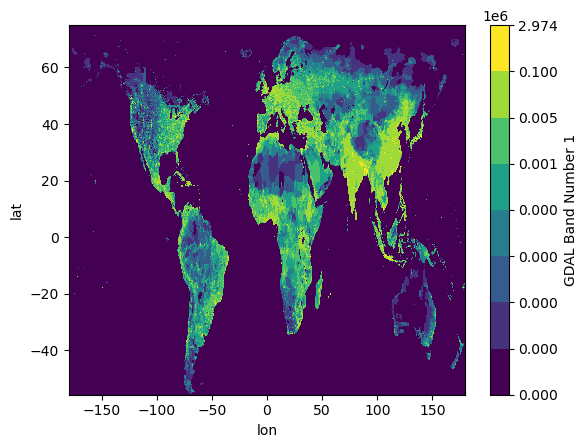

In [149]:
pop_2000.plot(levels=[0, 1, 25, 100, 250, 1000, 5000, 100000, pop_2000.max()])

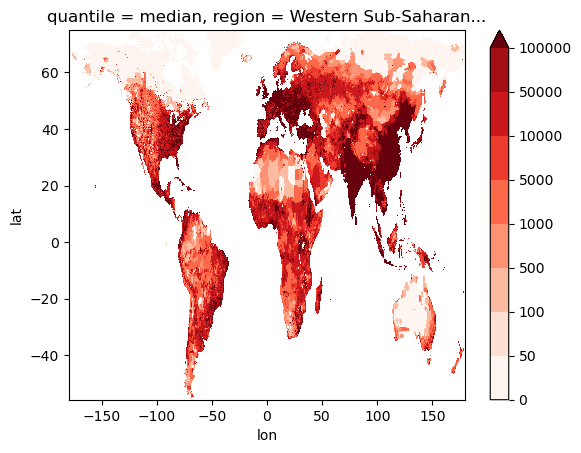

In [152]:
M_no_o3.sel(quantile="median").plot(cmap="Reds", levels=levels)

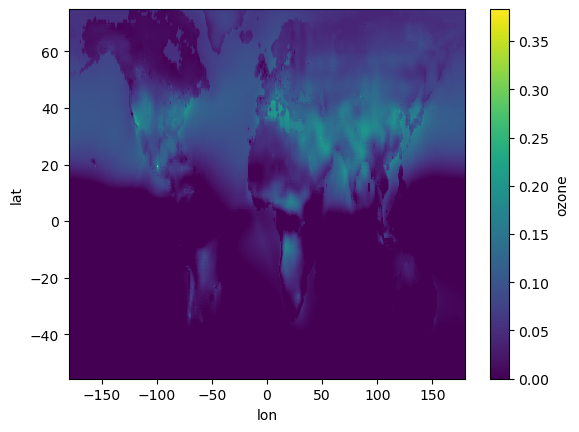

In [161]:
AF.plot()

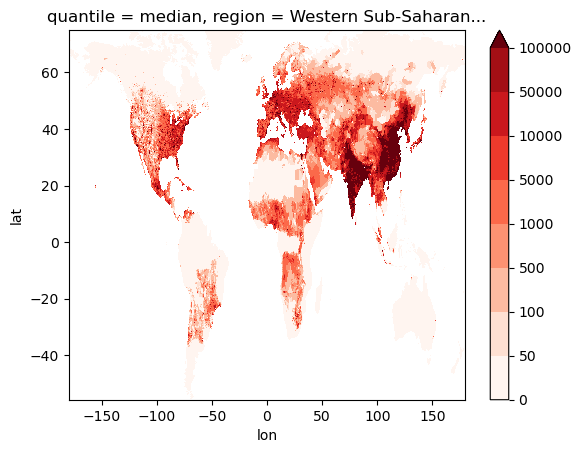

In [160]:
M.sel(quantile="median").plot(cmap="Reds", levels=levels)

In [163]:
weighted_sum(M - M_no_o3)

<xarray.DataArray (quantile: 3)> Size: 24B
array([-1.73733205e+11, -1.99549722e+11, -2.22867806e+11])
Coordinates:
  * quantile  (quantile) <U6 72B 'lower' 'median' 'upper'
    region    <U26 104B 'Western Sub-Saharan Africa'

In [164]:
np.exp(0)

1.0

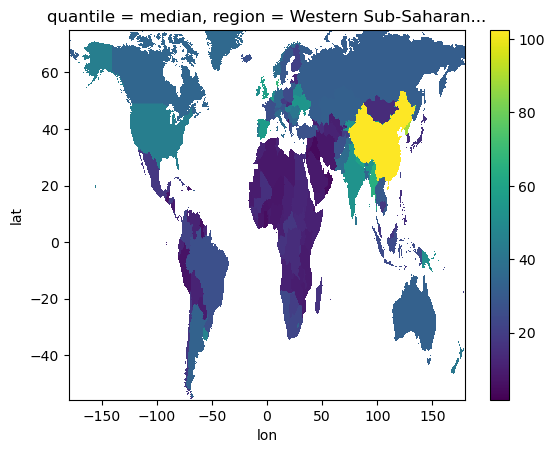

In [137]:
bmr_interp.sel(quantile="median").plot()

In [128]:
# === Latitude weighting sum ===
def weighted_sum(da):
    weights = np.cos(np.deg2rad(da.lat))
    weights.name = "weights"
    new_da = da.weighted(weights).sum(("lon", "lat"))
    return new_da


# === Latitude weighting mean ===
def weighted_mean(da):
    weights = np.cos(np.deg2rad(da.lat))
    weights.name = "weights"
    new_da = da.weighted(weights).mean(("lon", "lat"))
    return new_da

In [16]:
new_M = weighted_sum(M)

In [17]:
new_M

<xarray.DataArray (quantile: 3)> Size: 24B
array([2.14090277e+10, 2.45643667e+10, 2.74199395e+10])
Coordinates:
  * quantile  (quantile) <U6 72B 'lower' 'median' 'upper'
    region    <U26 104B 'Western Sub-Saharan Africa'

In [18]:
levels = [0, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]

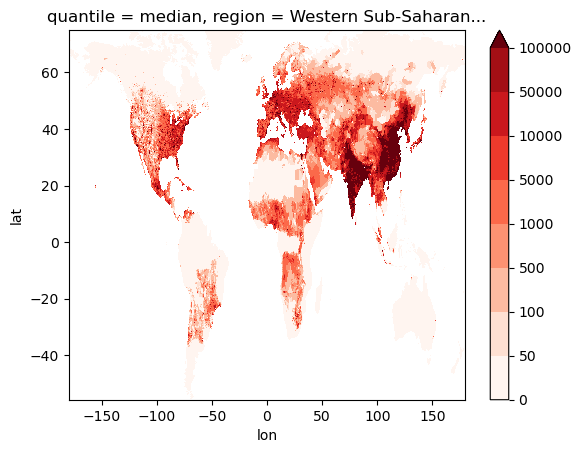

In [20]:
M.sel(quantile="median").plot(cmap="Reds", levels=levels)

In [133]:
M.sel(quantile="median").sum()

<xarray.DataArray ()> Size: 8B
array(2.91524839e+10)
Coordinates:
    quantile  <U6 24B 'median'
    region    <U26 104B 'Western Sub-Saharan Africa'

In [94]:
masks = xr.open_dataarray(f"{BMR_DIR}GBD_Country_Masks_0.10_newlabels.nc")

In [95]:
masks_lat_mask = xr.ufuncs.logical_and(masks.lat.values <= pop_lat.max(), masks.lat.values >= pop_lat.min())
new_masks = masks.sel(lat=masks_lat_mask)
masks_interp = new_masks.interp(lat=pop_2000.lat, lon=pop_2000.lon, method="linear")

In [118]:
# Create DataArray filled with NaNs
global_M_array = xr.DataArray(
    np.full((len(M.lat), len(M.lon)), np.nan),
    coords={"lat": M.lat.values, "lon": M.lon.values},
    dims=["lat", "lon"]
)

In [112]:
masks[37]

<xarray.DataArray 'country_mask' (lat: 1800, lon: 3600)> Size: 6MB
[6480000 values with dtype=int8]
Coordinates:
  * lat      (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.8 179.9
    region   <U28 112B ...
    country  <U52 208B 'United States of America'

In [129]:
# Loop over countries, add the population for each country and apply using country mask
for i in range(204):
    mask = masks_interp.isel(country=i)
    country = masks_interp.isel(country=i)["country"]
    M_country = weighted_mean(xr.where(masks_interp.isel(country=i) == 1, M.sel(quantile="median"), np.nan)) # mortality of country
    global_M_array = global_M_array.where(mask == 0, M_country)

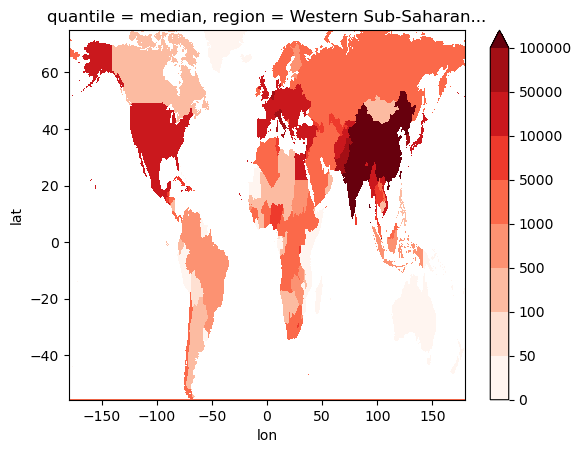

In [130]:
global_M_array.plot(cmap="Reds", levels=levels)

In [135]:
weighted_sum(global_M_array)

<xarray.DataArray ()> Size: 8B
array(2.56284244e+10)
Coordinates:
    quantile  <U6 24B 'median'
    region    <U28 112B 'Western Sub-Saharan Africa'